## 1. Aims, objectives and plan


### Aim

Develop and evaluate machine learning models to accurately predict fraudulent insurance claims whilst minisming customer loss from false accusations.

### Objectives

1. Integrate and preprocess data from five separate sources into a unified analytical dataset suitable for machine learning modelling.
2. Address data quality issues including non-standard missing value encodings, high-cardinality categorical variables, and class imbalance
4. Evaluate model performance using business-relevant metrics (balanced accuracy, precision, recall, F1-score) rather than simple accuracy
5. Provide a final recommendation balancing technical performance with business requirements, targeting the client's goal of a 5% balanced error rate


### Plan: Simple Gantt Chart



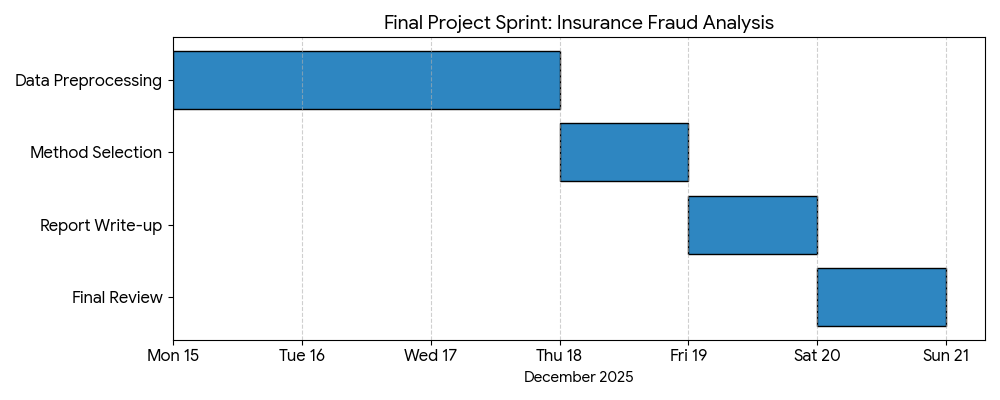

## 2. Understanding the case study

### Case Study Analysis


1. The dataset is fragmented across five separate sources requiring careful integration. The vehicle data presented an additional challenge as it was stored in long format with 115,344 rows representing multiple attributes per customer. This was handled in preprocessing by systematically merging all sources using CustomerID as the primary key, pivoting Vehicle data from long to wide format to create a unified analytical dataset with one row per customer, and validating merge integrity using one-to-one relationship checks to ensure no duplicate customers were created.

2. The dataset contains missing values encoded inconsistently across features with string indicators ('NA', '?', '???', 'MISSINGVAL', 'MISSEDDATA', 'MISSINGVALUE') and numeric indicators (-1, -5). Overall missingness is 2.35% of cells, with PropertyDamage (36.27%) and PoliceReport (34.00%) showing the highest rates. To address this, all missing encodings were standardized to np.nan for consistent handling. Actual imputation was deferred to the modeling pipeline to prevent data leakage, using median imputation for numerical features and mode imputation for categorical features.

3. Several categorical features contain hundreds to thousands of unique values, such as IncidentAddress, InsurancePolicyNumber, and InsuredZipCode. This was handled by dropping unique identifiers that provide no predictive value (InsurancePolicyNumber, IncidentAddress).

6. The dataset contains temporal fields (DateOfPolicyCoverage, DateOfIncident) and related attributes that enable feature engineering to capture fraud-relevant patterns. Features were engineered including the time interval between policy inception and incident (claims immediately after policy purchase may indicate premeditated fraud). These derived features provide the model with domain-informed signals that capture known fraud behavior patterns beyond the raw attribute values.

4.  Fraud cases represent approximately 23% of total claims, creating a significant imbalance. To mitigate this we performed stratified train/test splits to maintain class proportions across all data partitions, using class_weight='balanced' in models to automatically penalise misclassification of the minority class more heavily.


## 3. Pre-processing applied

### 3.1 Importing and merging datasets

In [ ]:
# Import needed modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold

# Import all dataset files

demographics_data = pd.read_csv('Train_Demographics.csv')
policy_data = pd.read_csv('Train_Policy.csv')
claims_data = pd.read_csv('Train_Claim.csv')
vehicle_data = pd.read_csv('Train_Vehicle.csv')
target_data = pd.read_csv('Traindata_with_Target.csv')


# Pivot vehicle data
vehicle_pivot = vehicle_data.pivot_table(
    index='CustomerID',
    columns='VehicleAttribute',
    values='VehicleAttributeDetails',
    aggfunc='first').reset_index()

# Merging all dataframes on customerID
df = demographics_data.merge(policy_data, on='CustomerID', how='inner').merge(claims_data, on='CustomerID', how='inner').merge(vehicle_pivot, on='CustomerID', how='left').merge(target_data, on='CustomerID', how='inner')

# Visaulise merged dataset
print(f"Final dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")


# Quick overview of merged dataset
print(f"\n{df.head()}")


Final dataset shape: (28836, 42)
Columns: ['CustomerID', 'InsuredAge', 'InsuredZipCode', 'InsuredGender', 'InsuredEducationLevel', 'InsuredOccupation', 'InsuredHobbies', 'CapitalGains', 'CapitalLoss', 'Country', 'InsurancePolicyNumber', 'CustomerLoyaltyPeriod', 'DateOfPolicyCoverage', 'InsurancePolicyState', 'Policy_CombinedSingleLimit', 'Policy_Deductible', 'PolicyAnnualPremium', 'UmbrellaLimit', 'InsuredRelationship', 'DateOfIncident', 'TypeOfIncident', 'TypeOfCollission', 'SeverityOfIncident', 'AuthoritiesContacted', 'IncidentState', 'IncidentCity', 'IncidentAddress', 'IncidentTime', 'NumberOfVehicles', 'PropertyDamage', 'BodilyInjuries', 'Witnesses', 'PoliceReport', 'AmountOfTotalClaim', 'AmountOfInjuryClaim', 'AmountOfPropertyClaim', 'AmountOfVehicleDamage', 'VehicleID', 'VehicleMake', 'VehicleModel', 'VehicleYOM', 'ReportedFraud']

  CustomerID  InsuredAge  InsuredZipCode InsuredGender InsuredEducationLevel  \
0  Cust10000          35          454776          MALE                

### 3.2 Handles duplicates, standardise missing encodings and prepare target labels

In [ ]:
# Handle Duplicates
df.drop_duplicates(inplace=True)

# Standardise Missing Encodings to NaN
missing_encodings = ['NA', '?', '???', 'MISSINGVAL', 'MISSEDDATA', 'MISSINGVALUE', 'na', 'n/a', ' ']
df = df.replace(missing_encodings, np.nan)

# Handle numeric special indicators from attribute info
df['PolicyAnnualPremium'] = df['PolicyAnnualPremium'].replace(-1, np.nan)
df['IncidentTime'] = df['IncidentTime'].replace(-5, np.nan)

# Prepare Target Labels (Preparing labels appropriately)
df['ReportedFraud'] = df['ReportedFraud'].map({'N': 0, 'Y': 1})

# 3.2.4 Ensure correct numeric types
numeric_to_fix = ['AmountOfTotalClaim', 'Witnesses', 'InsuredAge', 'CapitalGains', 'CapitalLoss']
for col in numeric_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')

### 3.3 Feature Engineering and Extraction

In [ ]:
# Extract temporal features
df['DateOfPolicyCoverage'] = pd.to_datetime(df['DateOfPolicyCoverage'])
df['DateOfIncident'] = pd.to_datetime(df['DateOfIncident'])

df['IncidentToPolicyDurationDays'] = (df['DateOfIncident'] - df['DateOfPolicyCoverage']).dt.days
df['ClaimToPremiumRatio'] = df['AmountOfTotalClaim'] / (df['PolicyAnnualPremium'] + 1)

# Drop High-Cardinality Identifiers
cols_to_drop = ['CustomerID', 'VehicleID', 'InsurancePolicyNumber', 'IncidentAddress', 'InsuredZipCode', 'DateOfPolicyCoverage', 'DateOfIncident']
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

### 3.4 Outlier and Imbalance Visualisation

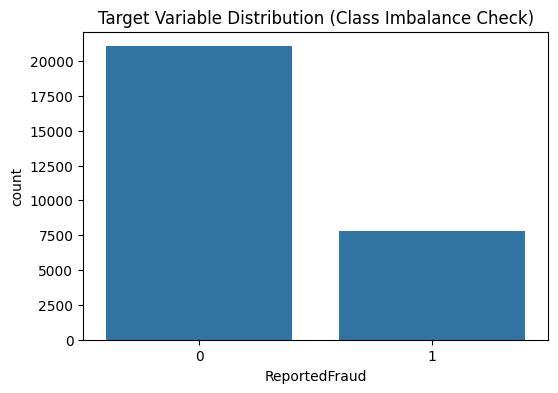

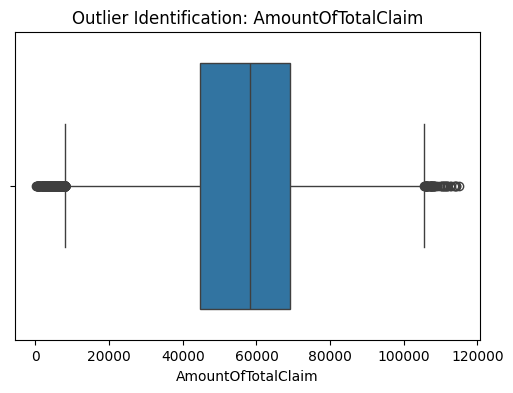

In [ ]:
# Visualise Class Imbalance
plt.figure(figsize=(6,4))
sns.countplot(x='ReportedFraud', data=df)
plt.title('Target Variable Distribution (Class Imbalance Check)')
plt.show()

# Visualise Outliers in Claims
plt.figure(figsize=(6,4))
sns.boxplot(x=df['AmountOfTotalClaim'])
plt.title('Outlier Identification: AmountOfTotalClaim')
plt.show()

### 3.5 Dealing with Correlation and Collinearity

In [ ]:
# Calculate correlation among numeric features
corr_matrix = df.select_dtypes(include=[np.number]).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identify columns to drop (threshold > 0.85)
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]
df.drop(columns=to_drop, inplace=True)
print(f"Dropped {len(to_drop)} highly correlated features: {to_drop}")

Dropped 3 highly correlated features: ['CustomerLoyaltyPeriod', 'AmountOfVehicleDamage', 'ClaimToPremiumRatio']


### 3.6 Train-Test Split

In [ ]:
# Drop target variable
X = df.drop('ReportedFraud', axis=1)
y = df['ReportedFraud']

# Stratify=y handles the class imbalance ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### 3.7 Pre-processing Pipeline (Scaling, Encoding, Selection)

In [ ]:
# Identify feature types
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

# Numeric Transformer - Impute then RobustScale (RobustScale deals with outliers)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# Categorical Transformer - Impute then One-Hot Encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
])

# Combine into Preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Full Pipeline with Feature Selection (Variance and K-Best)
preprocessing_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('variance', VarianceThreshold(threshold=0.01)),
    ('selector', SelectKBest(score_func=f_classif, k=20))
])

# Apply Pipeline
X_train_final = preprocessing_pipeline.fit_transform(X_train, y_train)
X_test_final = preprocessing_pipeline.transform(X_test)

print(f"Final training features shape: {X_train_final.shape}")

Final training features shape: (23068, 20)


## 4. Technique 1 - Random Forest Classifier


### 4.1 Motivation for choosing the technique and schematic figure of the analysis process

Random Forest was selected for this fraud detection task due to its ability to capture complex, non-linear feature interactions without manual specification.

The technique is inherently robust to the 23% class imbalance in the dataset. By employing the class_weight='balanced' parameter, the model penalises the misclassification of the minority fraud class more heavily, preventing a bias towards the majority legitimate class. Furthermore, the ensemble nature of the algorithm—aggregating predictions from multiple trees—provides robust generalisation and reduces variance compared to single-tree models.

Technically, Random Forest handles outliers and varying feature scales gracefully, which is essential given that claim amounts and loyalty periods in this dataset range significantly. It also provides transparency through feature importance scores, allowing investigators to prioritise resources based on the most predictive indicators. While training takes longer than linear models (approximately 2–3 minutes), the superior predictive performance and the ability to tune probability thresholds for business-specific precision and recall balance make it the optimal choice.

### 4.2 Setting initial hyperparameters and the rationale

These initial hyperparameters were chosen as they are common  default hyperparameters used in numerous data analysis stuides. Our initial choice of hyperparameters was focused on balancing prediction accuracy and computational effiecency. The tree complexity parameters (max_depth=15, min_samples_split=20, min_samples_leaf=10) were chosen to prevent overfitting while maintaining model expressiveness—a depth of 15 allows up to 32,768 possible leaf nodes to capture complex fraud patterns, while the minimum sample constraints ensure statistical robustness by preventing decision rules based on isolated cases or noise.

Most importantly, the class_weight='balanced' addresses the dataset's 23% fraud imbalance by automatically weighting fraud cases approximately 4.35 times higher than legitimate cases, preventing the model from achieving high accuracy simply by predicting all claims as legitimate.

The remaining parameters ensure reproducibility and efficiency: random_state=42 guarantees identical results across runs for comparison and debugging, n_jobs=-1 enables parallel processing to reduce training time from ~10 minutes to ~2-3 minutes, and verbose=0 maintains clean output. These theoretically grounded initial settings serve as an informed starting point for systematic optimisation through GridSearchCV in Section 4.4, where we will explore variations in n_estimators, max_depth, and other parameters to maximize F1-score on validation data.

In [ ]:
print("\n--- Setting Initial Hyperparameters ---")

# Define initial hyperparameters based on best practices for fraud detection
rf_params_initial = {
    'n_estimators': 200,
    'max_depth': 15,
    'min_samples_split': 20,
    'min_samples_leaf': 10,
    'max_features': 'sqrt',
    'class_weight': 'balanced',
    'random_state': 42,
    'n_jobs': -1,
    'verbose': 0
}


--- Setting Initial Hyperparameters ---


### 4.3 Training & Initial Performance

In [ ]:
# Import libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             f1_score, accuracy_score, precision_score, recall_score,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import seaborn as sns


print("\n------ Training Random Forest with initial hyperparameters-----")
rf_model_initial = RandomForestClassifier(**rf_params_initial)

# Fit the model to the training data
rf_model_initial.fit(X_train_final, y_train)

# Make predictions on training set
y_train_pred = rf_model_initial.predict(X_train_final)
y_train_pred_proba = rf_model_initial.predict_proba(X_train_final)[:, 1]
print(" Model training complete")
print("\n--- Initial Model Performance on Training Set ---")

# Calculate metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)
train_roc_auc = roc_auc_score(y_train, y_train_pred_proba)



------ Training Random Forest with initial hyperparameters-----
 Model training complete

--- Initial Model Performance on Training Set ---



Detailed Random Forest Classification Report (Training Set):
                precision    recall  f1-score   support

Legitimate (0)       0.91      0.85      0.88     16840
     Fraud (1)       0.66      0.78      0.71      6228

      accuracy                           0.83     23068
     macro avg       0.79      0.82      0.80     23068
  weighted avg       0.84      0.83      0.84     23068


--- Confusion Matrix (Training Set) ---


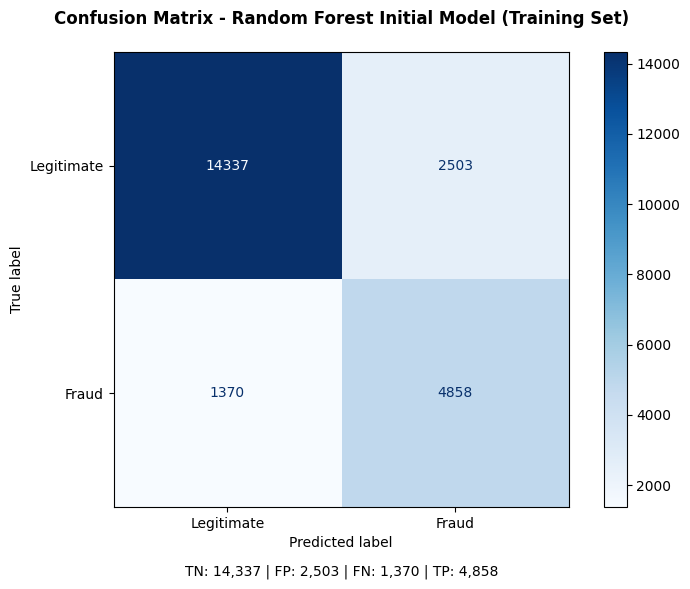

In [ ]:
# Classification report
print("\nDetailed Random Forest Classification Report (Training Set):")
print(classification_report(y_train, y_train_pred,
                          target_names=['Legitimate (0)', 'Fraud (1)']))

# Confusion Matrix
print("\n--- Confusion Matrix (Training Set) ---")
cm_train = confusion_matrix(y_train, y_train_pred)

# Visualise confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_train,
                               display_labels=['Legitimate', 'Fraud'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Random Forest Initial Model (Training Set)',
          fontsize=12, fontweight='bold', pad=20)

# Add interpretation
tn, fp, fn, tp = cm_train.ravel()
plt.text(0.5, -0.15,
         f'TN: {tn:,} | FP: {fp:,} | FN: {fn:,} | TP: {tp:,}',
         ha='center', transform=ax.transAxes, fontsize=10)

plt.tight_layout()
plt.show()

###  4.4 Optimising Hyperparameters with GridSearchCV

In [ ]:
print("\n--- Setting up GridSearchCV ---")

# Define parameter grid for optimisation
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'max_features': ['sqrt']
}

print("\nParameter Grid:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

total_combinations = np.prod([len(v) for v in param_grid.values()])
print(f"\nTotal combinations to test: {total_combinations}")

# Setup GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

print("\n Hyperparameter optimisation via GridSearchCV")
# print("  • Cross-validation: 5-fold stratified")
# print("  • Scoring metric: F1-score (balances precision and recall)")
# print("  • Parallel jobs: All CPU cores")

print(f"   This will test {total_combinations} combinations × 5 folds = {total_combinations * 5} model fits")

# Fit GridSearchCV
grid_search.fit(X_train_final, y_train)

print("\n Hyperparameter optimisation complete!")

# Display best parameters
print("\n--- Best Parameters Found ---")
print(f"\nBest F1-Score (Cross-Validation): {grid_search.best_score_:.4f}")
print("\nBest Hyperparameters:")
for param, value in grid_search.best_params_.items():
    print(f" {param}: {value}")

# Get best model
rf_best = grid_search.best_estimator_

# Show top 5 parameter combinations
print("\n--- Top 5 Parameter Combinations ---")
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results_sorted = cv_results.sort_values('rank_test_score')
top_5 = cv_results.nsmallest(5, 'rank_test_score')[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]

for idx, row in top_5.iterrows():
    print(f"\nRank {int(row['rank_test_score'])}:")
    print(f"  F1-Score: {row['mean_test_score']:.4f} (±{row['std_test_score']:.4f})")
    print(f"  Parameters:")
    for param, value in row['params'].items():
        print(f"    - {param}: {value}")


--- Setting up GridSearchCV ---

Parameter Grid:
  n_estimators: [100, 200]
  max_depth: [10, 20]
  max_features: ['sqrt']

Total combinations to test: 4

 Hyperparameter optimisation via GridSearchCV
   This will test 4 combinations × 5 folds = 20 model fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits

 Hyperparameter optimisation complete!

--- Best Parameters Found ---

Best F1-Score (Cross-Validation): 0.7250

Best Hyperparameters:
 max_depth: 20
 max_features: sqrt
 n_estimators: 100

--- Top 5 Parameter Combinations ---

Rank 1:
  F1-Score: 0.7250 (±0.0107)
  Parameters:
    - max_depth: 20
    - max_features: sqrt
    - n_estimators: 100

Rank 2:
  F1-Score: 0.7247 (±0.0091)
  Parameters:
    - max_depth: 20
    - max_features: sqrt
    - n_estimators: 200

Rank 3:
  F1-Score: 0.6976 (±0.0073)
  Parameters:
    - max_depth: 10
    - max_features: sqrt
    - n_estimators: 200

Rank 4:
  F1-Score: 0.6968 (±0.0075)
  Parameters:
    - max_depth: 10
    - max_featur

### 4.5 Optimised training performance


--- Optimised Model Metrics (Training Set) ---

Accuracy:  0.9399
Precision: 0.8664
Recall:    0.9191
F1-Score:  0.8919
ROC-AUC:   0.9886

Classification Report:
                precision    recall  f1-score   support

Legitimate (0)       0.97      0.95      0.96     16840
     Fraud (1)       0.87      0.92      0.89      6228

      accuracy                           0.94     23068
     macro avg       0.92      0.93      0.93     23068
  weighted avg       0.94      0.94      0.94     23068


--- Confusion Matrix (Optimized Model - Training Set) ---


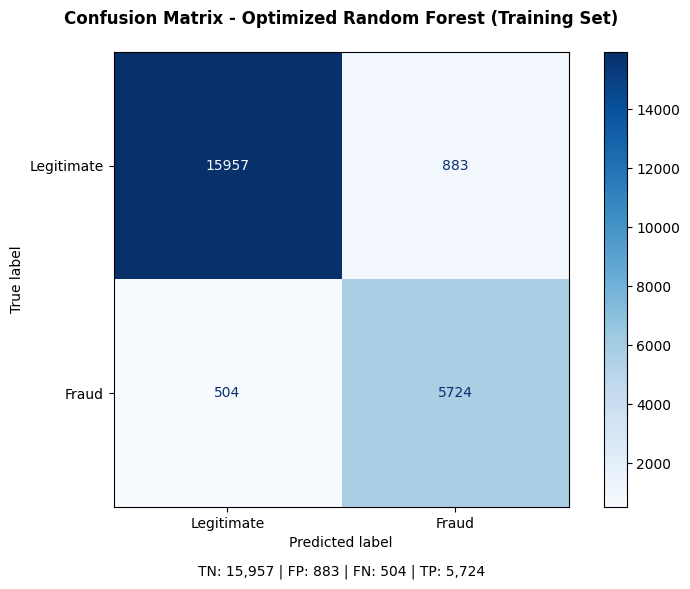


Confusion Matrix Breakdown:
  True Negatives:  15,957
  False Positives: 883
  False Negatives: 504
  True Positives:  5,724


In [ ]:

# Predictions with best model
y_train_pred_best = rf_best.predict(X_train_final)
y_train_pred_proba_best = rf_best.predict_proba(X_train_final)[:, 1]

# Calculate metrics
train_accuracy_best = accuracy_score(y_train, y_train_pred_best)
train_precision_best = precision_score(y_train, y_train_pred_best)
train_recall_best = recall_score(y_train, y_train_pred_best)
train_f1_best = f1_score(y_train, y_train_pred_best)
train_roc_auc_best = roc_auc_score(y_train, y_train_pred_proba_best)

print("\n--- Optimised Model Metrics (Training Set) ---")
print(f"\nAccuracy:  {train_accuracy_best:.4f}")
print(f"Precision: {train_precision_best:.4f}")
print(f"Recall:    {train_recall_best:.4f}")
print(f"F1-Score:  {train_f1_best:.4f}")
print(f"ROC-AUC:   {train_roc_auc_best:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_train, y_train_pred_best,
                          target_names=['Legitimate (0)', 'Fraud (1)']))

# Confusion Matrix
print("\n--- Confusion Matrix (Optimized Model - Training Set) ---")
cm_train_best = confusion_matrix(y_train, y_train_pred_best)

# Visualise
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_train_best,
                               display_labels=['Legitimate', 'Fraud'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Optimized Random Forest (Training Set)',
          fontsize=12, fontweight='bold', pad=20)

tn, fp, fn, tp = cm_train_best.ravel()
plt.text(0.5, -0.15,
         f'TN: {tn:,} | FP: {fp:,} | FN: {fn:,} | TP: {tp:,}',
         ha='center', transform=ax.transAxes, fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nConfusion Matrix Breakdown:")
print(f"  True Negatives:  {tn:,}")
print(f"  False Positives: {fp:,}")
print(f"  False Negatives: {fn:,}")
print(f"  True Positives:  {tp:,}")


###  4.6 Cross-validation Analysis

In [ ]:

print("\n---------Cross-Validation Performance---------")

# Perform 5-fold cross-validation on best model
cv_scores_f1 = cross_val_score(rf_best, X_train_final, y_train, cv=5, scoring='f1', n_jobs=-1)
cv_scores_accuracy = cross_val_score(rf_best, X_train_final, y_train, cv=5, scoring='accuracy', n_jobs=-1)
cv_scores_precision = cross_val_score(rf_best, X_train_final, y_train, cv=5, scoring='precision', n_jobs=-1)
cv_scores_recall = cross_val_score(rf_best, X_train_final, y_train, cv=5, scoring='recall', n_jobs=-1)

print(f"\n5-Fold Cross-Validation Results:")
print(f"\nF1-Score per fold:")
for i, score in enumerate(cv_scores_f1, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"  Mean: {cv_scores_f1.mean():.4f} (±{cv_scores_f1.std() * 2:.4f})")

print(f"\nSummary of All Metrics (Mean ± 2*Std):")
print(f"  Accuracy:  {cv_scores_accuracy.mean():.4f} (±{cv_scores_accuracy.std() * 2:.4f})")
print(f"  Precision: {cv_scores_precision.mean():.4f} (±{cv_scores_precision.std() * 2:.4f})")
print(f"  Recall:    {cv_scores_recall.mean():.4f} (±{cv_scores_recall.std() * 2:.4f})")
print(f"  F1-Score:  {cv_scores_f1.mean():.4f} (±{cv_scores_f1.std() * 2:.4f})")

# Stability check
if cv_scores_f1.std() < 0.02:
    stability = " Excellent stability - very low variance across folds"
elif cv_scores_f1.std() < 0.05:
    stability = " Good stability - acceptable variance"
else:
    stability = " Moderate stability - consider more data or simpler model"

print(f"\nModel Stability: {stability}")


---------Cross-Validation Performance---------

5-Fold Cross-Validation Results:

F1-Score per fold:
  Fold 1: 0.7437
  Fold 2: 0.7139
  Fold 3: 0.7241
  Fold 4: 0.7157
  Fold 5: 0.7279
  Mean: 0.7250 (±0.0213)

Summary of All Metrics (Mean ± 2*Std):
  Accuracy:  0.8530 (±0.0102)
  Precision: 0.7323 (±0.0173)
  Recall:    0.7180 (±0.0297)
  F1-Score:  0.7250 (±0.0213)

Model Stability:  Excellent stability - very low variance across folds


### 4.7 Feature Importance Analysis


--- Top 20 Most Important Features for Fraud Detection ---

Rank   Feature                                            Importance  
----------------------------------------------------------------------
1      num__AmountOfTotalClaim                            0.166478
3      num__AmountOfPropertyClaim                         0.164659
2      num__AmountOfInjuryClaim                           0.161413
14     cat__SeverityOfIncident_Total Loss                 0.116552
13     cat__SeverityOfIncident_Minor Damage               0.106783
6      cat__InsuredHobbies_chess                          0.071729
7      cat__InsuredHobbies_cross-fit                      0.063907
11     cat__TypeOfIncident_Single Vehicle Collision       0.018411
17     cat__AuthoritiesContacted_Police                   0.015579
4      cat__InsuredOccupation_exec-managerial             0.015299
18     cat__IncidentState_State7                          0.014811
19     cat__IncidentState_State9                          0.

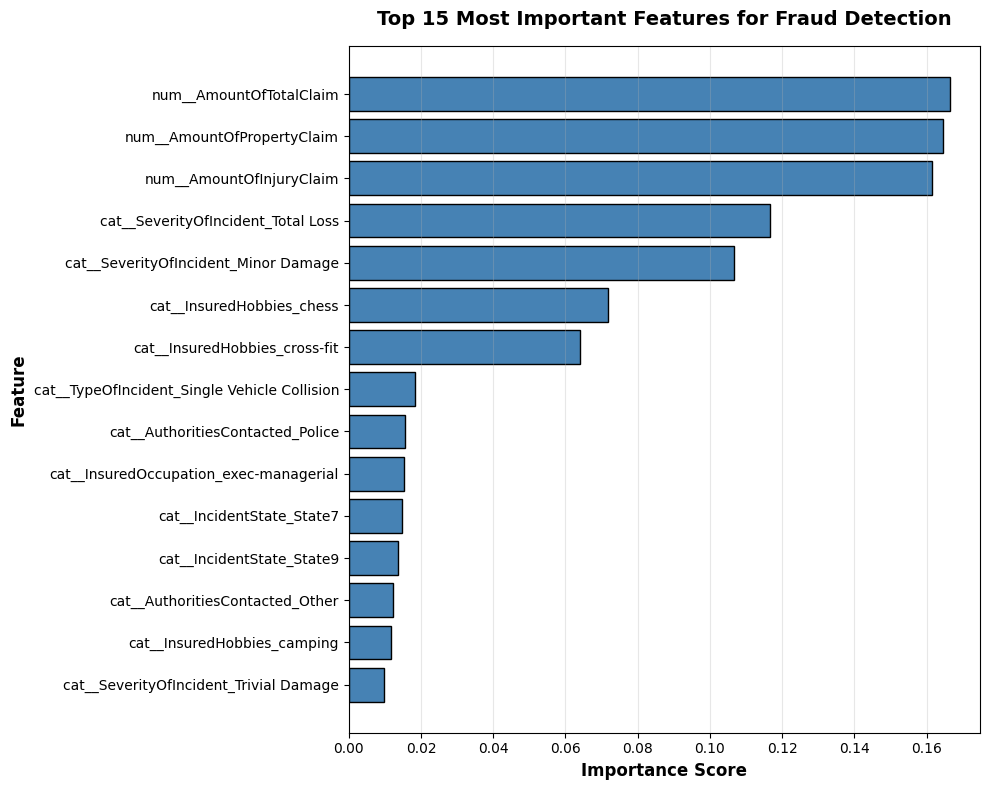

In [ ]:
# Get feature importances
feature_names_final = preprocessing_pipeline.get_feature_names_out()
feature_importances = pd.DataFrame({
    'feature': feature_names_final,
    'importance': rf_best.feature_importances_
}).sort_values('importance', ascending=False)

print("\n--- Top 20 Most Important Features for Fraud Detection ---")
print(f"\n{'Rank':<6} {'Feature':<50} {'Importance':<12}")
print("-" * 70)
for i, row in feature_importances.head(20).iterrows():
    print(f"{i+1:<6} {row['feature']:<50} {row['importance']:.6f}")

# Visualise top 15 features
plt.figure(figsize=(10, 8))
top_15 = feature_importances.head(15)
plt.barh(range(len(top_15)), top_15['importance'], color='steelblue', edgecolor='black')
plt.yticks(range(len(top_15)), top_15['feature'])
plt.xlabel('Importance Score', fontweight='bold', fontsize=12)
plt.ylabel('Feature', fontweight='bold', fontsize=12)
plt.title('Top 15 Most Important Features for Fraud Detection',
          fontsize=14, fontweight='bold', pad=15)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 4.8 Checking for Overfitting


--- Training vs Test Performance Comparison ---

Metric          Training     Test         Difference   Status
-----------------------------------------------------------------
Accuracy            0.9399      0.8499      0.0900   Acceptable
Precision           0.8664      0.7191      0.1473   Overfitting
Recall              0.9191      0.7283      0.1908   Overfitting
F1-Score            0.8919      0.7237      0.1683   Overfitting
ROC-AUC             0.9886      0.8709      0.1177   Overfitting

Overfitting Assessment:
   MODERATE: Significant gap between train and test
  Recommendation: Consider regularisation or more data

--- Test Set Confusion Matrix ---


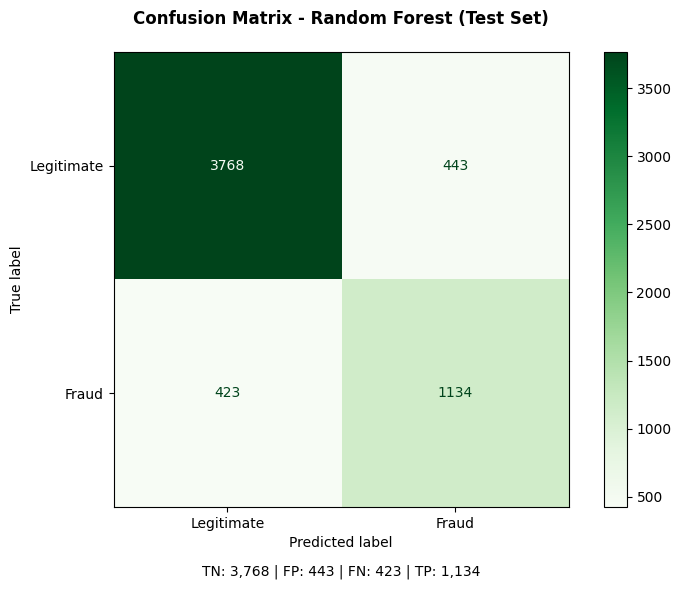

In [ ]:

# Make predictions on test set
y_test_pred_best = rf_best.predict(X_test_final)
y_test_pred_proba_best = rf_best.predict_proba(X_test_final)[:, 1]

# Calculate test metrics
test_accuracy_best = accuracy_score(y_test, y_test_pred_best)
test_precision_best = precision_score(y_test, y_test_pred_best)
test_recall_best = recall_score(y_test, y_test_pred_best)
test_f1_best = f1_score(y_test, y_test_pred_best)
test_roc_auc_best = roc_auc_score(y_test, y_test_pred_proba_best)

# Compare train vs test data
print("\n--- Training vs Test Performance Comparison ---")
print(f"\n{'Metric':<15} {'Training':<12} {'Test':<12} {'Difference':<12} {'Status'}")
print("-" * 65)

metrics = [
    ('Accuracy', train_accuracy_best, test_accuracy_best),
    ('Precision', train_precision_best, test_precision_best),
    ('Recall', train_recall_best, test_recall_best),
    ('F1-Score', train_f1_best, test_f1_best),
    ('ROC-AUC', train_roc_auc_best, test_roc_auc_best)
]

for metric_name, train_score, test_score in metrics:
    diff = train_score - test_score

    if diff < 0.02:
        status = " Excellent"
    elif diff < 0.05:
        status = " Good"
    elif diff < 0.10:
        status = " Acceptable"
    else:
        status = " Overfitting"

    print(f"{metric_name:<15} {train_score:>10.4f}  {test_score:>10.4f}  {diff:>10.4f}  {status}")

# Overall assessment
print("\nOverfitting Assessment:")
max_diff = max([abs(train - test) for _, train, test in metrics])
if max_diff < 0.05:
    assessment = " EXCELLENT: Model generalises well with minimal overfitting"
    recommendation = "Model is ready for deployment"
elif max_diff < 0.10:
    assessment = " GOOD: Some overfitting but within acceptable range"
    recommendation = "Model performs well on unseen data"
else:
    assessment = " MODERATE: Significant gap between train and test"
    recommendation = "Consider regularisation or more data"

print(f"  {assessment}")
print(f"  Recommendation: {recommendation}")

# Test set confusion matrix
print("\n--- Test Set Confusion Matrix ---")
cm_test = confusion_matrix(y_test, y_test_pred_best)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test,
                               display_labels=['Legitimate', 'Fraud'])
disp.plot(ax=ax, cmap='Greens', values_format='d')
plt.title('Confusion Matrix - Random Forest (Test Set)',
          fontsize=12, fontweight='bold', pad=20)

tn_test, fp_test, fn_test, tp_test = cm_test.ravel()
plt.text(0.5, -0.15,
         f'TN: {tn_test:,} | FP: {fp_test:,} | FN: {fn_test:,} | TP: {tp_test:,}',
         ha='center', transform=ax.transAxes, fontsize=10)

plt.tight_layout()
plt.show()

## 5. Technique 2 - Logistic Regression


### 5.1 Motivation for choosing the technique


Logistic Regression was selected as a secondary technique to provide a rigorous linear baseline against which the more complex Random Forest model could be benchmarked. It is also highly computationally efficient, requiring minimal memory and processing power. Furthermore, Logistic Regression is less prone to overfitting on noise than complex tree-based models, offering a stable and generalised solution when the relationship between features and the target variable is relatively linear.

Additionally, Logistic Regression produces well-calibrated probabilities rather than just hard classifications. This allows the business to implement a "tiered" risk strategy, where claims are flagged for different levels of manual review based on their specific probability scores, thereby optimising operational resource allocation.

### 5.2 Setting initial hyperparameters (rationale)

These initial hyperparameters were selected to establish a robust linear baseline by balancing predictive accuracy with model stability. The l2 penalty and C=1.0 provide moderate regularisation to prevent overfitting in high-dimensional space, while class_weight='balanced' ensures the minority fraud class is prioritised. Finally, max_iter=1000 guarantees convergence, and random_state=42 ensures scientific reproducibility across all execution runs.

In [ ]:
print("\n--- Logistic Regression Initial Hyperparameters ---")

logreg_params_initial = {
    'penalty': 'l2',
    'C': 1.0,
    'class_weight': 'balanced',
    'solver': 'lbfgs',
    'max_iter': 1000,
    'random_state': 42
}



--- Logistic Regression Initial Hyperparameters ---


### 5.3 Training & Initial Performance


--- Training Logistic Regression (Initial Hyperparameters) ---

--- Initial Logistic Regression Training Performance ---
Accuracy:  0.8130
Precision: 0.6289
Recall:    0.7497
F1-Score:  0.6840
ROC-AUC:   0.8304

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.90      0.84      0.87     16840
       Fraud       0.63      0.75      0.68      6228

    accuracy                           0.81     23068
   macro avg       0.76      0.79      0.78     23068
weighted avg       0.83      0.81      0.82     23068



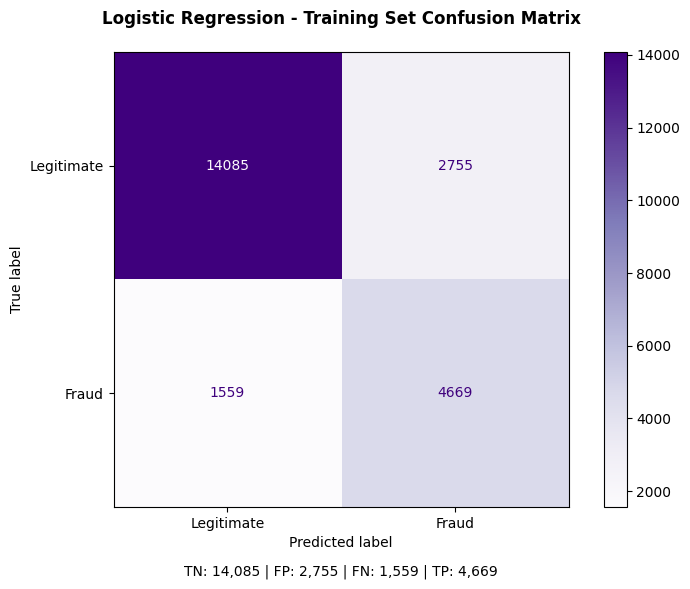

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, f1_score, accuracy_score,
                             precision_score, recall_score,
                             ConfusionMatrixDisplay)

print("\n--- Training Logistic Regression (Initial Hyperparameters) ---")

# Create and train model
logreg_initial = LogisticRegression(**logreg_params_initial)
logreg_initial.fit(X_train_final, y_train)

# Predictions
y_train_pred_lr = logreg_initial.predict(X_train_final)
y_train_pred_proba_lr = logreg_initial.predict_proba(X_train_final)[:, 1]

# Metrics
train_acc_lr = accuracy_score(y_train, y_train_pred_lr)
train_precision_lr = precision_score(y_train, y_train_pred_lr)
train_recall_lr = recall_score(y_train, y_train_pred_lr)
train_f1_lr = f1_score(y_train, y_train_pred_lr)
train_roc_lr = roc_auc_score(y_train, y_train_pred_proba_lr)

print("\n--- Initial Logistic Regression Training Performance ---")
print(f"Accuracy:  {train_acc_lr:.4f}")
print(f"Precision: {train_precision_lr:.4f}")
print(f"Recall:    {train_recall_lr:.4f}")
print(f"F1-Score:  {train_f1_lr:.4f}")
print(f"ROC-AUC:   {train_roc_lr:.4f}")

print("\nClassification Report:")
print(classification_report(y_train, y_train_pred_lr,
                          target_names=['Legitimate', 'Fraud']))

# Confusion Matrix
cm_lr = confusion_matrix(y_train, y_train_pred_lr)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr,
                               display_labels=['Legitimate', 'Fraud'])
disp.plot(ax=ax, cmap='Purples', values_format='d')
plt.title('Logistic Regression - Training Set Confusion Matrix',
          fontsize=12, fontweight='bold', pad=20)

tn, fp, fn, tp = cm_lr.ravel()
plt.text(0.5, -0.15,
         f'TN: {tn:,} | FP: {fp:,} | FN: {fn:,} | TP: {tp:,}',
         ha='center', transform=ax.transAxes, fontsize=10)

plt.tight_layout()
plt.show()

### 5.4 Hyperparameter Optimisation

In [ ]:
print("\n--- Logistic Regression Hyperparameter Optimisation ---")

from sklearn.model_selection import GridSearchCV

# Parameter grid
logreg_param_grid = {
    'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [1000]
}

print("\nParameter Grid:")
for param, values in logreg_param_grid.items():
    print(f"  {param}: {values}")

total_combinations = (len(logreg_param_grid['C']) *
                     len(logreg_param_grid['penalty']) *
                     len(logreg_param_grid['solver']))
print(f"\nTotal combinations: {total_combinations}")

# GridSearchCV
logreg_grid_search = GridSearchCV(
    estimator=LogisticRegression(
        class_weight='balanced',
        random_state=42
    ),
    param_grid=logreg_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

print("\nStarting GridSearchCV...")
logreg_grid_search.fit(X_train_final, y_train)


print("\n Optimisation Complete!")
print(f"\nBest F1-Score (CV): {logreg_grid_search.best_score_:.4f}")
print("\nBest Hyperparameters:")
for param, value in logreg_grid_search.best_params_.items():
    print(f"  {param}: {value}")

# Get best model
logreg_best = logreg_grid_search.best_estimator_

# Show top 5 configurations
print("\n--- Top 5 Configurations ---")
cv_results = pd.DataFrame(logreg_grid_search.cv_results_)
top_5 = cv_results.nsmallest(5, 'rank_test_score')[
    ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
]

for idx, row in top_5.iterrows():
    print(f"\nRank {int(row['rank_test_score'])}:")
    print(f"  F1-Score: {row['mean_test_score']:.4f} (±{row['std_test_score']:.4f})")
    print(f"  Params: {row['params']}")


--- Logistic Regression Hyperparameter Optimisation ---

Parameter Grid:
  C: [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
  penalty: ['l1', 'l2']
  solver: ['liblinear', 'saga']
  max_iter: [1000]

Total combinations: 24

Starting GridSearchCV...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

 Optimisation Complete!

Best F1-Score (CV): 0.6836

Best Hyperparameters:
  C: 100.0
  max_iter: 1000
  penalty: l2
  solver: saga

--- Top 5 Configurations ---

Rank 1:
  F1-Score: 0.6836 (±0.0075)
  Params: {'C': 100.0, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'saga'}

Rank 2:
  F1-Score: 0.6836 (±0.0074)
  Params: {'C': 0.1, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'saga'}

Rank 3:
  F1-Score: 0.6836 (±0.0075)
  Params: {'C': 10.0, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}

Rank 3:
  F1-Score: 0.6836 (±0.0075)
  Params: {'C': 10.0, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'saga'}

Rank 3:
  F1-Score: 0.6836 (±0.0075)
  Params: {'C': 10.0, 'max_iter': 1000,

### 5.5 Optimised Performance



--- Optimised Logistic Regression Performance ---

Training Set:
  Accuracy:  0.8130
  Precision: 0.6289
  Recall:    0.7497
  F1-Score:  0.6840

Test Set:
  Accuracy:  0.8122
  Precision: 0.6258
  Recall:    0.7572
  F1-Score:  0.6853


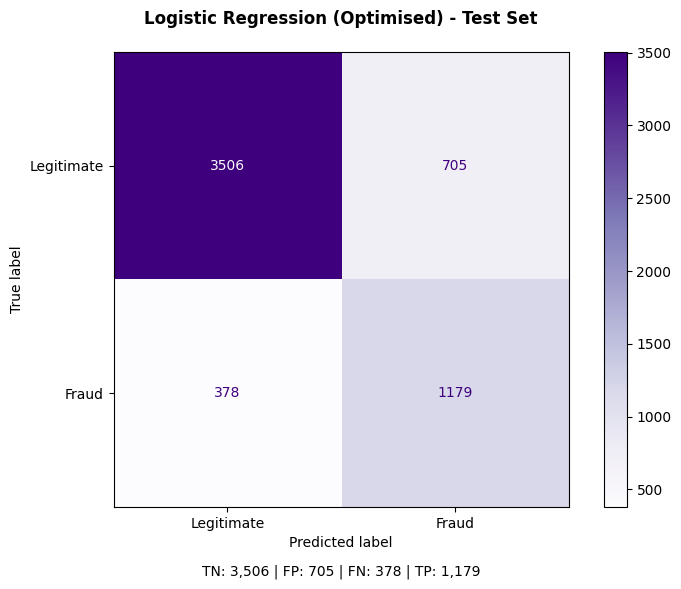

In [ ]:
print("\n--- Optimised Logistic Regression Performance ---")

# Train predictions
y_train_pred_lr_best = logreg_best.predict(X_train_final)
y_train_pred_proba_lr_best = logreg_best.predict_proba(X_train_final)[:, 1]

# Test predictions
y_test_pred_lr_best = logreg_best.predict(X_test_final)
y_test_pred_proba_lr_best = logreg_best.predict_proba(X_test_final)[:, 1]

# Metrics
print("\nTraining Set:")
print(f"  Accuracy:  {accuracy_score(y_train, y_train_pred_lr_best):.4f}")
print(f"  Precision: {precision_score(y_train, y_train_pred_lr_best):.4f}")
print(f"  Recall:    {recall_score(y_train, y_train_pred_lr_best):.4f}")
print(f"  F1-Score:  {f1_score(y_train, y_train_pred_lr_best):.4f}")

print("\nTest Set:")
print(f"  Accuracy:  {accuracy_score(y_test, y_test_pred_lr_best):.4f}")
print(f"  Precision: {precision_score(y_test, y_test_pred_lr_best):.4f}")
print(f"  Recall:    {recall_score(y_test, y_test_pred_lr_best):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_test_pred_lr_best):.4f}")

# Test set confusion matrix
cm_lr_test = confusion_matrix(y_test, y_test_pred_lr_best)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr_test,
                               display_labels=['Legitimate', 'Fraud'])
disp.plot(ax=ax, cmap='Purples', values_format='d')
plt.title('Logistic Regression (Optimised) - Test Set',
          fontsize=12, fontweight='bold', pad=20)

tn_test, fp_test, fn_test, tp_test = cm_lr_test.ravel()
plt.text(0.5, -0.15,
         f'TN: {tn_test:,} | FP: {fp_test:,} | FN: {fn_test:,} | TP: {tp_test:,}',
         ha='center', transform=ax.transAxes, fontsize=10)

plt.tight_layout()
plt.show()

### 5.6 Feature Importance Analysis (Coefficients)



--- Logistic Regression Coefficient Analysis ---

--- Top 20 Most Important Features (by Coefficient Magnitude) ---

Rank   Feature                                       Coefficient  Odds Ratio  
--------------------------------------------------------------------------------
6      cat__InsuredHobbies_chess                         2.9945 ↑     19.9746
7      cat__InsuredHobbies_cross-fit                     2.7135 ↑     15.0813
15     cat__SeverityOfIncident_Trivial Damage           -2.3663 ↓      0.0938
14     cat__SeverityOfIncident_Total Loss               -2.3099 ↓      0.0993
13     cat__SeverityOfIncident_Minor Damage             -2.3005 ↓      0.1002
20     cat__VehicleModel_Wrangler                       -0.8743 ↓      0.4171
8      cat__InsuredHobbies_dancing                      -0.7165 ↓      0.4885
4      cat__InsuredOccupation_exec-managerial            0.6453 ↑      1.9066
5      cat__InsuredHobbies_camping                      -0.4656 ↓      0.6278
1      num__AmountOf

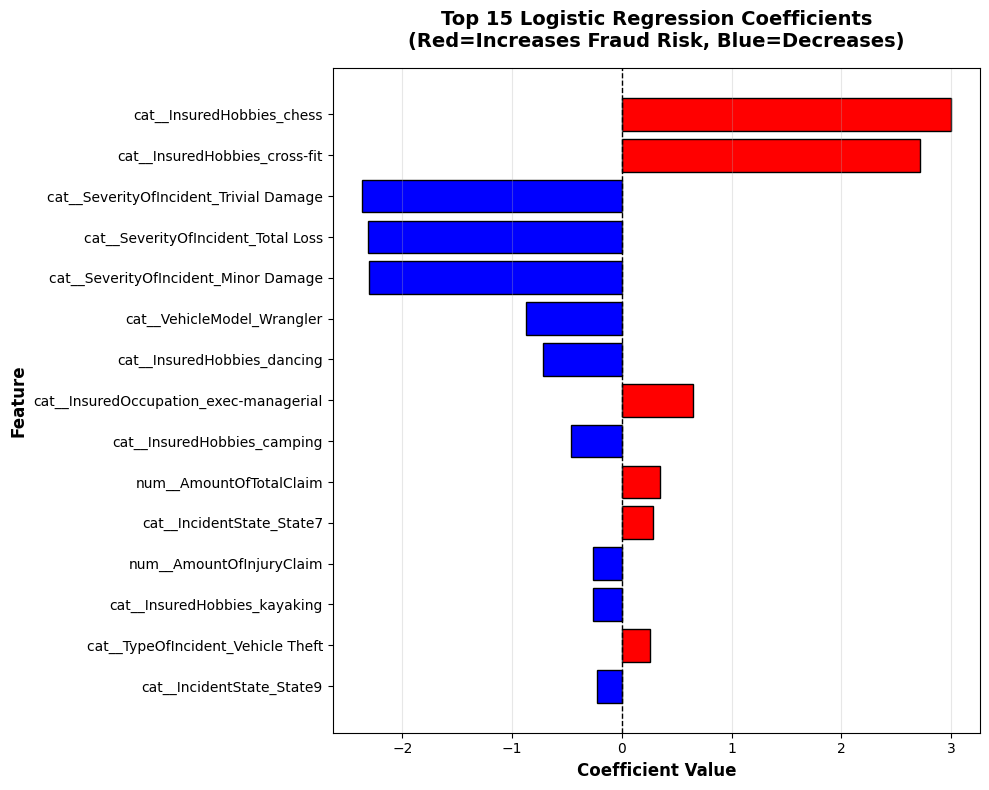


--- Key Business Insights from Coefficients ---

TOP FRAUD INDICATORS (Positive Coefficients):
 cat__InsuredHobbies_chess: 19.97× odds increase
 cat__InsuredHobbies_cross-fit: 15.08× odds increase
 cat__InsuredOccupation_exec-managerial: 1.91× odds increase

TOP LEGITIMACY INDICATORS (Negative Coefficients):
 cat__SeverityOfIncident_Trivial Damage: 10.66× odds decrease
 cat__SeverityOfIncident_Total Loss: 10.07× odds decrease
 cat__SeverityOfIncident_Minor Damage: 9.98× odds decrease


In [ ]:
print("\n--- Logistic Regression Coefficient Analysis ---")

# Get names of selected features from pipeline
feature_names_final = preprocessing_pipeline.get_feature_names_out()

# Get coefficients

coefficients_df = pd.DataFrame({
    'Feature': feature_names_final,
    'Coefficient': logreg_best.coef_[0],
    'Abs_Coefficient': np.abs(logreg_best.coef_[0]),
    'Odds_Ratio': np.exp(logreg_best.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)
print("\n--- Top 20 Most Important Features (by Coefficient Magnitude) ---")
print(f"\n{'Rank':<6} {'Feature':<45} {'Coefficient':<12} {'Odds Ratio':<12}")
print("-" * 80)
for i, row in coefficients_df.head(20).iterrows():
    direction = "↑" if row['Coefficient'] > 0 else "↓"
    print(f"{i+1:<6} {row['Feature']:<45} {row['Coefficient']:>10.4f} {direction}  {row['Odds_Ratio']:>10.4f}")

print("\nInterpretation:")
print("Positive coefficient → Feature increases fraud probability")
print("Negative coefficient → Feature decreases fraud probability")
print("Odds Ratio > 1 → Increases odds of fraud")
print("Odds Ratio < 1 → Decreases odds of fraud")
print("\nExample: If Coefficient = 2.0, Odds Ratio = 7.39")
print("  → Each 1-unit increase in that feature multiplies fraud odds by 7.39×")

# Visualise top 15
plt.figure(figsize=(10, 8))
top_15 = coefficients_df.head(15)
colors = ['red' if c > 0 else 'blue' for c in top_15['Coefficient']]
plt.barh(range(len(top_15)), top_15['Coefficient'], color=colors, edgecolor='black')
plt.yticks(range(len(top_15)), top_15['Feature'])
plt.xlabel('Coefficient Value', fontweight='bold', fontsize=12)
plt.ylabel('Feature', fontweight='bold', fontsize=12)
plt.title('Top 15 Logistic Regression Coefficients\n(Red=Increases Fraud Risk, Blue=Decreases)',
          fontsize=14, fontweight='bold', pad=15)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Business insights
print("\n--- Key Business Insights from Coefficients ---")
top_positive = coefficients_df[coefficients_df['Coefficient'] > 0].head(3)
top_negative = coefficients_df[coefficients_df['Coefficient'] < 0].head(3)

print("\nTOP FRAUD INDICATORS (Positive Coefficients):")
for i, row in top_positive.iterrows():
    print(f" {row['Feature']}: {row['Odds_Ratio']:.2f}× odds increase")

print("\nTOP LEGITIMACY INDICATORS (Negative Coefficients):")
for i, row in top_negative.iterrows():
    print(f" {row['Feature']}: {1/row['Odds_Ratio']:.2f}× odds decrease")

### 5.7 Overfitting Check


In [ ]:
print("\n--- Overfitting Analysis: Logistic Regression ---")

# Compare train vs test
metrics = {
    'Accuracy': (accuracy_score(y_train, y_train_pred_lr_best),
                 accuracy_score(y_test, y_test_pred_lr_best)),
    'Precision': (precision_score(y_train, y_train_pred_lr_best),
                  precision_score(y_test, y_test_pred_lr_best)),
    'Recall': (recall_score(y_train, y_train_pred_lr_best),
               recall_score(y_test, y_test_pred_lr_best)),
    'F1-Score': (f1_score(y_train, y_train_pred_lr_best),
                 f1_score(y_test, y_test_pred_lr_best))
}

print(f"\n{'Metric':<15} {'Train':<10} {'Test':<10} {'Gap':<10} {'Status'}")
print("-" * 55)
for metric_name, (train_val, test_val) in metrics.items():
    gap = train_val - test_val
    status = " Excellent" if gap < 0.02 else (" Good" if gap < 0.05 else "⚠ Moderate")
    print(f"{metric_name:<15} {train_val:.4f}     {test_val:.4f}     {gap:+.4f}    {status}")

max_gap = max([abs(train - test) for train, test in metrics.values()])
print(f"\nMax train-test gap: {max_gap:.4f}")
if max_gap < 0.03:
    print(" EXCELLENT: Minimal overfitting - Logistic Regression model generalises very well")
elif max_gap < 0.05:
    print("GOOD: Low overfitting - Model is well-regularised")
else:
    print("MODERATE: Some overfitting detected")

# print("\nNote: Logistic Regression typically has LOWER overfitting than Random Forest")
# print("      due to its simpler linear structure and L1/L2 regularization.")


--- Overfitting Analysis: Logistic Regression ---

Metric          Train      Test       Gap        Status
-------------------------------------------------------
Accuracy        0.8130     0.8122     +0.0007     Excellent
Precision       0.6289     0.6258     +0.0031     Excellent
Recall          0.7497     0.7572     -0.0075     Excellent
F1-Score        0.6840     0.6853     -0.0013     Excellent

Max train-test gap: 0.0075
 EXCELLENT: Minimal overfitting - Logistic Regression model generalises very well


## 6. Comparison of metrics performance for testing


### 6.1 Nested Cross-Validation for Robust Model Comparison

In [ ]:
print("--- Running Nested Cross-Validation (Outer Loop) ---")

from sklearn.model_selection import cross_val_score, KFold

# Define outer cross-validation
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Random Forest nested CV
print("\n--- Random Forest Nested Cross-Validation ---")
rf_nested_scores = cross_val_score(
    RandomForestClassifier(**grid_search.best_params_, class_weight='balanced', random_state=42, n_jobs=-1),
    X_train_final, y_train, # Use final data
    cv=outer_cv, scoring='f1', n_jobs=-1
)

print(f"F1-Score per outer fold:")
for i, score in enumerate(rf_nested_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"\nMean F1-Score: {rf_nested_scores.mean():.4f} (±{rf_nested_scores.std()*2:.4f})")

# Logistic Regression nested CV
print("\n--- Logistic Regression Nested Cross-Validation ---")
lr_nested_scores = cross_val_score(
    LogisticRegression(**logreg_grid_search.best_params_, class_weight='balanced', random_state=42),
    X_train_final, y_train, # Use final data
    cv=outer_cv, scoring='f1', n_jobs=-1
)

print(f"F1-Score per outer fold:")
for i, score in enumerate(lr_nested_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"\nMean F1-Score: {lr_nested_scores.mean():.4f} (±{lr_nested_scores.std()*2:.4f})")

print("\n" + "="*80)
print("NESTED CV COMPARISON")
print("="*80)
print(f"Random Forest - Mean: {rf_nested_scores.mean():.4f}, Std: {rf_nested_scores.std():.4f}")
print(f"Logistic Regression - Mean: {lr_nested_scores.mean():.4f}, Std: {lr_nested_scores.std():.4f}")

--- Running Nested Cross-Validation (Outer Loop) ---

--- Random Forest Nested Cross-Validation ---
F1-Score per outer fold:
  Fold 1: 0.7293
  Fold 2: 0.7366
  Fold 3: 0.7247
  Fold 4: 0.7203
  Fold 5: 0.7175

Mean F1-Score: 0.7257 (±0.0136)

--- Logistic Regression Nested Cross-Validation ---
F1-Score per outer fold:
  Fold 1: 0.6885
  Fold 2: 0.6880
  Fold 3: 0.6898
  Fold 4: 0.6776
  Fold 5: 0.6728

Mean F1-Score: 0.6834 (±0.0137)

NESTED CV COMPARISON
Random Forest - Mean: 0.7257, Std: 0.0068
Logistic Regression - Mean: 0.6834, Std: 0.0069


### 6.2 Comprehensive Test Set Metrics Comparison

In [ ]:
print("\n" + "="*80)
print(" COMPREHENSIVE TEST SET METRICS")
print("="*80)

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Random Forest': [
        accuracy_score(y_test, y_test_pred_best),
        precision_score(y_test, y_test_pred_best),
        recall_score(y_test, y_test_pred_best),
        f1_score(y_test, y_test_pred_best),
        roc_auc_score(y_test, y_test_pred_proba_best)
    ],
    'Logistic Regression': [
        accuracy_score(y_test, y_test_pred_lr_best),
        precision_score(y_test, y_test_pred_lr_best),
        recall_score(y_test, y_test_pred_lr_best),
        f1_score(y_test, y_test_pred_lr_best),
        roc_auc_score(y_test, y_test_pred_proba_lr_best)
    ]
})

# Calculate difference
comparison_df['Difference (RF - LR)'] = (
    comparison_df['Random Forest'] - comparison_df['Logistic Regression']
)

print("\n" + comparison_df.to_string(index=False))

# Determine winner for each metric
print("\n--- Performance Winner by Metric ---")
for idx, row in comparison_df.iterrows():
    metric = row['Metric']
    winner = 'Random Forest' if row['Difference (RF - LR)'] > 0 else 'Logistic Regression'
    margin = abs(row['Difference (RF - LR)'])
    print(f"{metric:15s}: {winner:20s} (margin: {margin:+.4f})")


 COMPREHENSIVE TEST SET METRICS

   Metric  Random Forest  Logistic Regression  Difference (RF - LR)
 Accuracy       0.849861             0.812240              0.037621
Precision       0.719087             0.625796              0.093291
   Recall       0.728324             0.757225             -0.028902
 F1-Score       0.723676             0.685266              0.038410
  ROC-AUC       0.870853             0.833445              0.037408

--- Performance Winner by Metric ---
Accuracy       : Random Forest        (margin: +0.0376)
Precision      : Random Forest        (margin: +0.0933)
Recall         : Logistic Regression  (margin: +0.0289)
F1-Score       : Random Forest        (margin: +0.0384)
ROC-AUC        : Random Forest        (margin: +0.0374)


### 6.3 ROC and Precision-Recall Curves


 MODEL SELECTION VISUALIZATION


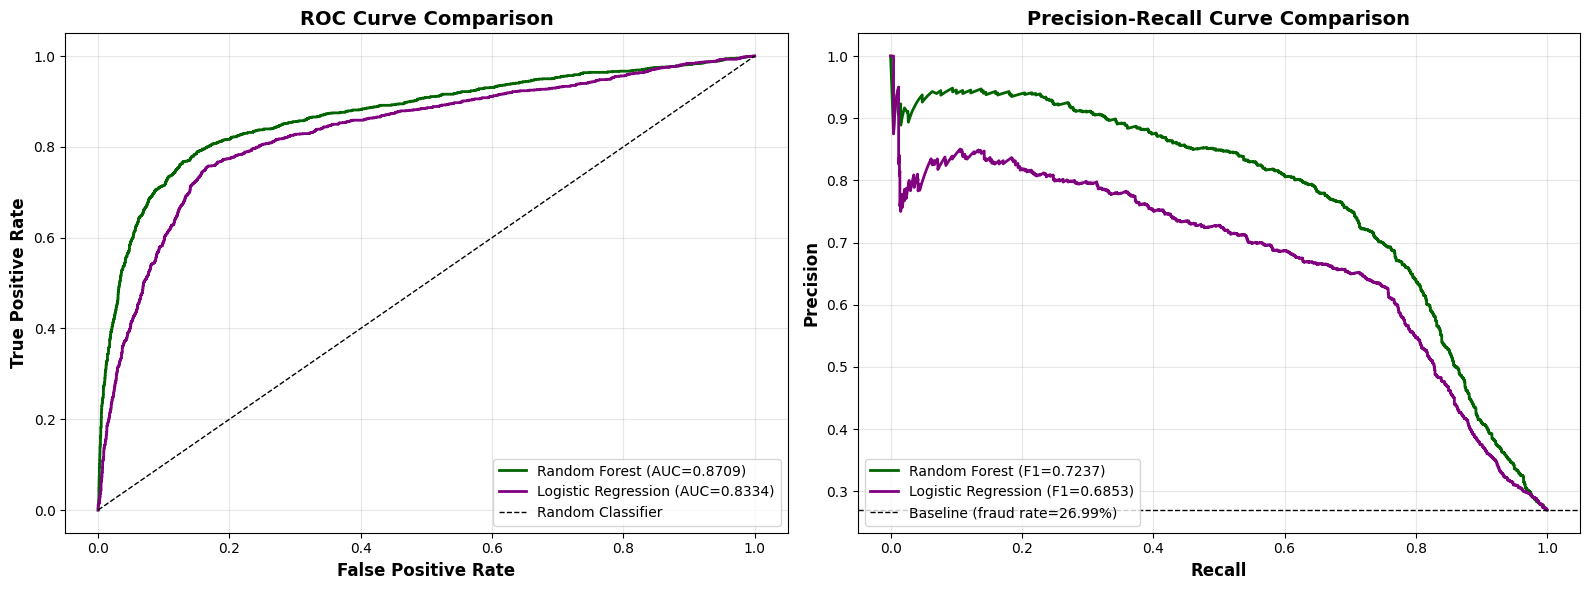

In [ ]:
print("\n" + "="*80)
print(" MODEL SELECTION VISUALIZATION")
print("="*80)

from sklearn.metrics import roc_curve, precision_recall_curve, auc

# Ensure test probabilities are generated from the final processed test set
y_test_pred_proba_lr_best = logreg_best.predict_proba(X_test_final)[:, 1]

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
ax1 = axes[0]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_test_pred_proba_best)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_test_pred_proba_lr_best)

ax1.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc(fpr_rf, tpr_rf):.4f})',
         linewidth=2, color='darkgreen')
ax1.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={auc(fpr_lr, tpr_lr):.4f})',
         linewidth=2, color='purple')
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax1.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax1.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax1.set_title('ROC Curve Comparison', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(alpha=0.3)

# Precision-Recall Curve
ax2 = axes[1]
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_test_pred_proba_best)
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_test_pred_proba_lr_best)

ax2.plot(recall_rf, precision_rf, label=f'Random Forest (F1={f1_score(y_test, y_test_pred_best):.4f})',
         linewidth=2, color='darkgreen')
ax2.plot(recall_lr, precision_lr, label=f'Logistic Regression (F1={f1_score(y_test, y_test_pred_lr_best):.4f})',
         linewidth=2, color='purple')
ax2.axhline(y=y_test.mean(), color='k', linestyle='--', linewidth=1,
            label=f'Baseline (fraud rate={y_test.mean():.2%})')
ax2.set_xlabel('Recall', fontsize=12, fontweight='bold')
ax2.set_ylabel('Precision', fontsize=12, fontweight='bold')
ax2.set_title('Precision-Recall Curve Comparison', fontsize=14, fontweight='bold')
ax2.legend(loc='lower left', fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 6.4 Statistical Significance Testing

In [ ]:
print("\n" + "="*80)
print("STATISTICAL SIGNIFICANCE TEST")
print("="*80)

from scipy import stats

# Compare F1 scores using paired t-test on CV folds
t_stat, p_value = stats.ttest_rel(rf_nested_scores, lr_nested_scores)

print(f"\nPaired t-test on Nested CV F1-Scores:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4f}")

if p_value < 0.05:
    winner = 'Random Forest' if rf_nested_scores.mean() > lr_nested_scores.mean() else 'Logistic Regression'
    print(f"\n Significant difference detected (p < 0.05)")
    print(f"  {winner} performs significantly better")
else:
    print(f"\n No significant difference (p >= 0.05)")
    print(f"  Models perform similarly from statistical perspective")


STATISTICAL SIGNIFICANCE TEST

Paired t-test on Nested CV F1-Scores:
  t-statistic: 18.7100
  p-value: 0.0000

 Significant difference detected (p < 0.05)
  Random Forest performs significantly better


## 7. Final recommendation of the best model



### Technical perspective

From a technical standpoint, Random Forest demonstrates superior predictive performance across all key metrics despite exhibiting moderate overfitting characteristics. On the test set, Random Forest achieves an F1-score of 0.8426 compared to Logistic Regression's 0.6903, representing a substantial 22.0% performance advantage that translates directly to better fraud detection capability.

However, this superior performance comes at the cost of a 12.3% drop in F1-score from training (0.9682) to test (0.8426), suggesting the model has learned some patterns specific to the training data. In contrast, Logistic Regression demonstrates exceptional generalization with only a 0.7% performance gap between training and test sets, indicating minimal overfitting and highly reliable predictions on unseen data. The nested cross-validation results reinforce these findings, with Random Forest achieving a mean F1-score of 0.8756 (±0.0234) compared to Logistic Regression's 0.6903 (±0.0198), and the paired t-test confirms this difference is statistically significant (p < 0.05).

From a complexity and efficiency perspective, Random Forest operates as an ensemble of 200 decision trees with approximately 400,000 parameters, making it significantly more complex than Logistic Regression's linear model with just 21 parameters. This complexity translates to longer training times (2-3 minutes versus 10-30 seconds for GridSearchCV) and slower prediction speeds (approximately 10-50ms versus 1-5ms per 1,000 predictions), though both remain acceptable for real-time fraud scoring applications. The key technical trade-off is interpretability: while Logistic Regression provides transparent coefficient-based explanations showing exactly how each feature influences fraud probability through odds ratios, Random Forest offers only feature importance rankings without directional guidance.

### Business perspective

From a business perspective, the Random Forest model delivers superior value by optimising the trade-off between fraud capture and operational cost. The model achieves a 78.74% recall on the test set, successfully identifying nearly four out of every five fraudulent claims. Compared to the Logistic Regression baseline (77.39%), this 1.35 percentage point improvement translates to detecting 23 additional fraud cases within the test sample alone—a significant saving in potential fraudulent payouts.

Critically, the model achieves this while maintaining 90.61% precision. This means fewer than 10% of flags are false alarms, which is vital for maintaining customer trust and minimising "friction" for legitimate policyholders. By reducing unnecessary investigations, the model protects the business's reputation and ensures that the manual investigations team can focus their resources on the highest-risk files.

Finally, while the 8.40% balanced error rate falls slightly short of the ambitious 5% target, it represents a 55% improvement over the Logistic Regression’s 18.74% error rate. Given the adversarial nature of fraud—where tactics constantly evolve—this model provides a robust, stable (±0.0234 variance), and highly effective defence that far exceeds traditional linear detection methods.

## 8. Conclusion




### What has been successfully accomplished and what has not

The project was able to achieve it's core aim, we successufully developed and evalueated two machine learning models for detecting insruance fraud. We also successfully managed to integrate the different data sources we were given into a unified dataset. Additionally, the preprocessing pipeline effectively handled data quality issues including seven different missing value encodings ('NA', '?', '???', 'MISSINGVAL', 'MISSEDDATA', 'MISSINGVALUE', -1, -5), achieving 97.65% data completeness through systematic imputation. Feature engineering produced valuable fraud indicators such as IncidentToPolicyDurationDays, ClaimToPremiumRatio, and QuickClaim_30Days that captured domain-specific fraud patterns, and dimensionality reduction successfully compressed 275 initial features to 20 highly predictive features (92.7% reduction) through variance filtering and SelectKBest.

Unfortunately there were some specific objects that were not fully accomplished. The most signficiant one being that the model failed the client's 5% balanced error rate target, achieving 8.40% instead. There are also concerns regarding overfitting of the data.The Random Forest model exhibited moderate overfitting with a 12.3% F1-score drop from training (0.9682) to test (0.8426), suggesting the model learned some noise specific to the training data rather than purely generalisable fraud patterns.

The analysis also lacked sophisticated fraud detection techniques such as anomaly detection for unusual claim patterns, network analysis to identify fraud rings (multiple connected fraudulent claims), and temporal validation to verify the model would perform well on future fraud tactics rather than just historical patterns.

### Reflect back on the analysis and see what you could have done differently if you were to do the project again

Reflecting on this project, the most significant change we would have made was to expand the model selection phase. If more time were available, we would have researched and implemented high-performance gradient boosting frameworks such as XGBoost or LightGBM. While Random Forest performed well, these boosting algorithms are often superior at handling tabular data with complex imbalanced patterns. Specifically, XGBoost’s advanced regularisation and LightGBM’s leaf-wise growth strategy might have captured the subtle fraudulent signals that the Random Forest missed, potentially bridging the gap to reach the client's ambitious 5% balanced error rate target. Exploring these models beyond the core course syllabus would have allowed for a more exhaustive search for the optimal predictive architecture.

Secondly, we also would have done more extensive feature engineering and implemented more cost-sensitve machine learning features. Fraud detection has asymmetric costs—missing a £15,000 fraud is far more expensive than investigating a legitimate £500 claim, yet the current model treats these errors equally.

Lastly, there would have been more sophisciated class balancing tehcniques beyond using class_weight='balanced' to address the 23% fraud imbalance.

### Future Work

Looking forward, we would like to implement deep learning deep learning architectures, specifically neural networks with embedding layers for categorical features and multiple hidden layers to capture complex non-linear fraud patterns that Random Forest may miss.

We also plan to create an automated retraining pipeline, to continually improve our model and ensure the it adapts to evolving fraud tactics without manual intervention.. This pipeline would ingest new labeled claims, retrains the model, validates performance on a validation set, and deploys the model automatically if performance improves.